# Modelo de clasificación de Imágenes de One Piece
### Arturo Sánchez Rodríguez | A01275427

In [1]:
#Importar las librerías que vamos a utilizar en el proyecto de clasificación de imágenes
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping)

In [2]:

onePiece_data = "OnePiece/Data/Data" #Definimos la ruta de nuestro dataset para luego poder llamarlo
print(os.listdir("OnePiece/Data/Data/")[::]) #Vemos las clases que tenemos en nuestro dataset

#A diferencia con el dataset de MNIST que ya tiene las imágenes convertidas en números y listas para ser utilizadas, con nuestro modelo no esta asi entonces como la computadora no puede ver las imágenes tenemos que convertirlos en números.

def cargar_img(path, img_size=(64, 64)):
    images = []
    labels = []

    class_names = sorted([
        clase for clase in os.listdir(path)
        if os.path.isdir(os.path.join(path, clase))
    ])

    for label_index, class_name in enumerate(class_names):
        class_path = os.path.join(path, class_name)
        for file_name in os.listdir(class_path):
            if file_name.lower().endswith((".png", ".jpg", "jpeg")):
                img_path = os.path.join(class_path, file_name)
                img = tf.keras.utils.load_img(img_path, target_size=img_size)
                img_array = tf.keras.utils.img_to_array(img)
                images.append(img_array)
                labels.append(label_index)
    images = np.array(images)
    labels = np.array(labels)

    return images, labels, class_names

images, labels, class_names = cargar_img(onePiece_data)

#Imprimimos la forma de las imágenes, etiquetas, nombres de clases y la cantidad de clases para verificar que todo se haya cargado correctamente
print(images.shape)
print(labels.shape)
print(class_names)
print(len(class_names))


['Akainu', '.DS_Store', 'Sanji', 'Jinbei', 'Nami', 'Law', 'Crocodile', 'Mihawk', 'Chopper', 'Zoro', 'Shanks', 'Brook', 'Rayleigh', 'Usopp', 'Kurohige', 'Franky', 'Ace', 'Luffy', 'Robin']


/Users/arturosr/Library/Python/3.11/lib/python/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


(11737, 64, 64, 3)
(11737,)
['Ace', 'Akainu', 'Brook', 'Chopper', 'Crocodile', 'Franky', 'Jinbei', 'Kurohige', 'Law', 'Luffy', 'Mihawk', 'Nami', 'Rayleigh', 'Robin', 'Sanji', 'Shanks', 'Usopp', 'Zoro']
18


In [3]:
#Separamos el dataset en TRAIN y TEST
train_img, test_img, train_labels, test_labels = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train imágenes:", train_img.shape)
print("Test imágenes:", test_img.shape)
print("Train labels:", train_labels.shape)
print("Test labels:", test_labels.shape)

Train imágenes: (9389, 64, 64, 3)
Test imágenes: (2348, 64, 64, 3)
Train labels: (9389,)
Test labels: (2348,)


In [4]:

def scale_img(train_img, test_img):
    train_img = train_img / 255.
    test_img = test_img / 255.
    return train_img, test_img



train_img, test_img = scale_img(train_img, test_img)

print("train_img.shape:", train_img.shape)
print("test_img.shape:", test_img.shape)
print("train_img.min():", train_img.min(), "train_img.max():", train_img.max())
print("test_img.min():", test_img.min(), "test_img.max():", test_img.max())

train_img.shape: (9389, 64, 64, 3)
test_img.shape: (2348, 64, 64, 3)
train_img.min(): 0.0 train_img.max(): 1.0
test_img.min(): 0.0 test_img.max(): 1.0


In [5]:
np.save("train_img.npy", train_img)
np.save("test_img.npy", test_img)

np.save("train_labels.npy", train_labels)
np.save("test_labels.npy", test_labels)

np.save("class_names.npy", class_names)

print("Se guardaron los test y train en formato .npy de manera correcta!")

Se guardaron los test y train en formato .npy de manera correcta!


# Modelo

In [6]:
#Tenemos que definir cuántas clases tiene nuestro dataset

num_classes = len(class_names)
print("Número de clases:", num_classes)
print("Clases:", class_names)

Número de clases: 18
Clases: ['Ace', 'Akainu', 'Brook', 'Chopper', 'Crocodile', 'Franky', 'Jinbei', 'Kurohige', 'Law', 'Luffy', 'Mihawk', 'Nami', 'Rayleigh', 'Robin', 'Sanji', 'Shanks', 'Usopp', 'Zoro']


In [7]:
#implementamos data augmentation para mejorar el rendimiento del modelo 2 CNN y evitar overfitting

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
    layers.RandomFlip("vertical")
])


In [8]:
def get_model_CNN_V2(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,

        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        
        layers.Conv2D(256, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model
model_cnn_v2 = get_model_CNN_V2(input_shape=(64, 64, 3), num_classes=num_classes)
model_cnn_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915,154 (3.49 MB)

 Trainable params: 915,154 (3.49 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

compile_model(model_cnn_v2)

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_best = ModelCheckpoint(
    filepath="best_model.keras", 
    monitor="val_accuracy", 
    save_best_only=True, 
    verbose=0
)

In [11]:
def train_model(model, train_img, train_labels):
    history = model.fit(train_img, train_labels, validation_split=0.2, epochs=50, batch_size=64, callbacks=[checkpoint_best])
    return history

history = train_model(model_cnn_v2, train_img, train_labels)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.0731 - loss: 2.8614 - val_accuracy: 0.0852 - val_loss: 2.8849
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.1194 - loss: 2.7421 - val_accuracy: 0.1326 - val_loss: 2.8166
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.1843 - loss: 2.5646 - val_accuracy: 0.1944 - val_loss: 2.5212
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.2484 - loss: 2.3864 - val_accuracy: 0.2311 - val_loss: 2.5217
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.2976 - loss: 2.2399 - val_accuracy: 0.2497 - val_loss: 2.3630
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.3394 - loss: 2.1165 - val_accuracy: 0.2945 - val_loss: 2.3367
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.3777 - loss: 1.9917 - val_accuracy: 0.3339 - val_loss: 2.2020
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.4235 - loss: 1.8720 - val_accu

In [12]:
#Evaluamos el modelo con el set de prueba
test_loss, test_accuracy = model_cnn_v2.evaluate(test_img, test_labels)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6759 - loss: 1.3355
Test loss: 1.3354626893997192
Test accuracy: 0.6758943796157837


In [13]:
# Resultados 

print(history.history["accuracy"][-1])
print(history.history["val_accuracy"][-1])

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)


0.8141392469406128
0.6703940629959106
Test accuracy: 0.6758943796157837
Test loss: 1.3354626893997192


In [14]:
#Vamos a calcular otras métricas de evaluación como precisión, recall, F1-score y matriz de confusión para tener una visión más completa del rendimiento del modelo.
y_pred_probs = model_cnn_v2.predict(test_img)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_labels
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

accuracy = accuracy_score(test_labels, y_pred_classes)
precision = precision_score(test_labels, y_pred_classes, average="weighted")
recall = recall_score(test_labels, y_pred_classes, average="weighted")
f1 = f1_score(test_labels, y_pred_classes, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Accuracy : 0.6758943781942078
Precision: 0.6980432372929618
Recall   : 0.6758943781942078
F1 Score : 0.6795333311333324


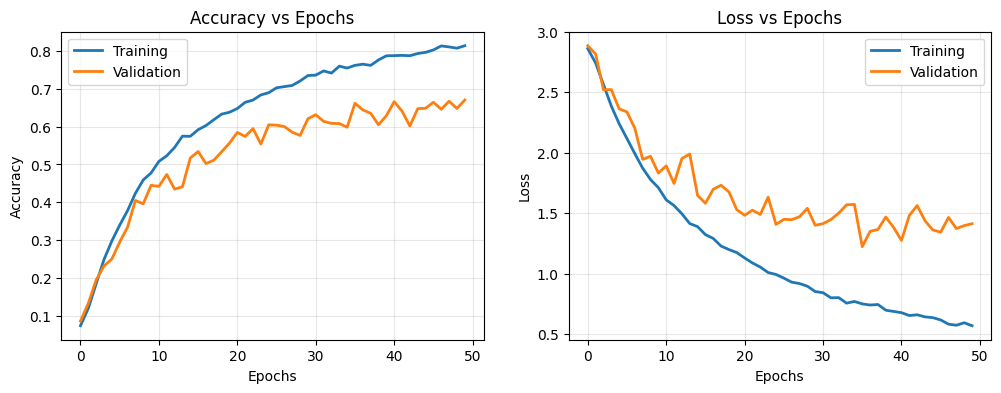

In [15]:
frame = pd.DataFrame(history.history)

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(train_acc, label="Training", linewidth=2)
plt.plot(val_acc, label="Validation", linewidth=2)
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(train_loss, label="Training", linewidth=2)
plt.plot(val_loss, label="Validation", linewidth=2)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

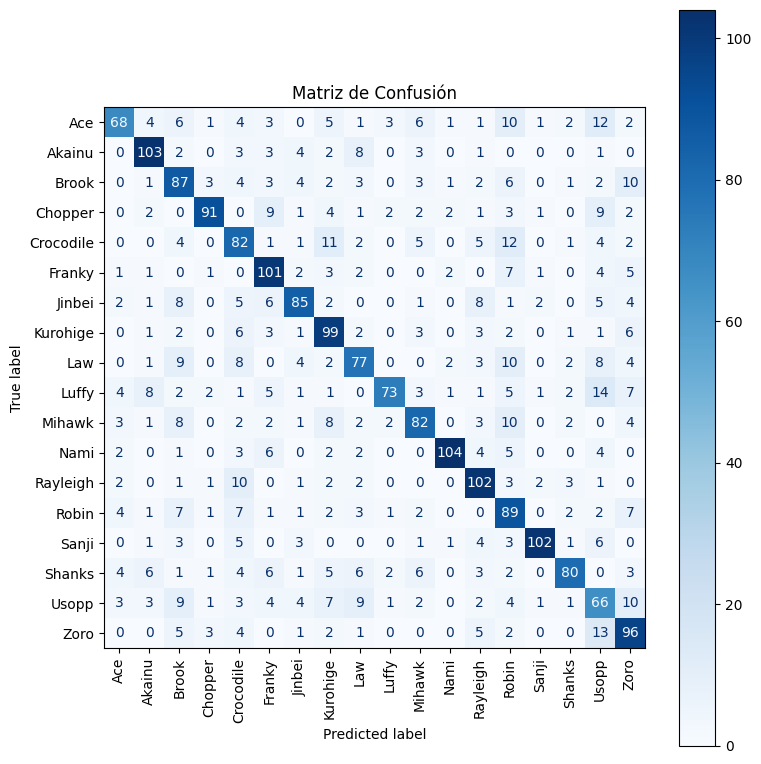

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, y_pred_classes)
fig , ax = plt.subplots(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=True)
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

## Guardar el Modelo

In [17]:
model_cnn_v2.save("onepiece_model.keras")
print("Modelo guardado correctamente!")


#Asi se recupera el modelo que se guardo
"""
loaded_model = tf.keras.models.load_model(
    "onepiece_model.keras"
)
"""

Modelo guardado correctamente!


'\nloaded_model = tf.keras.models.load_model(\n    "onepiece_model.keras"\n)\n'

# Probar el modelo con Queries

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicción: Brook
Confianza: 0.99998987


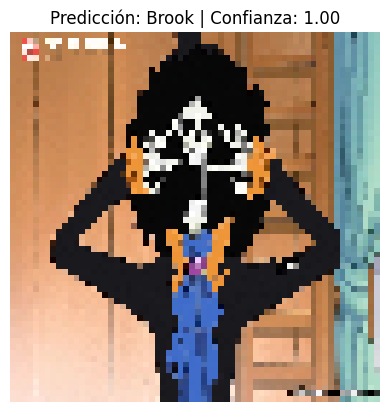

(np.str_('Brook'), np.float32(0.99998987))

In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

class_names = np.load("class_names.npy", allow_pickle=True) #Cargamos los nombres de las clases para la predicción

# Cargar el modelo guardado
model_query = tf.keras.models.load_model("best_model.keras")#Cargamos el modelo que guardamos con el mejor rendimiento para hacer las predicciones

# Función para preparar una imagen nueva
def cargar_imagen_query(image_path, img_size=(64, 64)): 
    img = tf.keras.utils.load_img(image_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array
#Cargamos la imagen que queremos que el modelo haga predicción y la preparamos para que pueda procesarla)

# Función para predecir una imagen 
def predecir_imagen(image_path):
    img, img_array = cargar_imagen_query(image_path)

    predictions = model_query.predict(img_array)#Hacemos la predicción con el modelo cargado utilizando la imagen que preparamos

    predicted_index = np.argmax(predictions[0])#Obtenemos el índice de la clase con la mayor probabilidad
    confidence = np.max(predictions[0])#Obtenemos la confianza de la predicción 

    predicted_class = class_names[predicted_index]#Sacamos el nombre de la clase de la predicción

    print("Predicción:", predicted_class)
    print("Confianza:", confidence)

    plt.imshow(img)
    plt.title(f"Predicción: {predicted_class} | Confianza: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

#La ruta de la imagen que queremos predecir
image_path = "/Users/arturosr/Desktop/OnePiece/OnePieceImage/Imagenes/OnePieceImagnesPrueba/14.png"

predecir_imagen(image_path)